In [2]:
from graphviz import Digraph
import math

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [20]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, other):
        # This line is added later
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other): # other + self
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            # _backward is basically derivative of self**other
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        # This line is added later
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    # This is something not needed, it is a python trick to be able to do
    # a = Value(3.0)
    # 2 * a --> This can be done because of __rmul__
    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        # We have to set this or else it will be 0.
        self.grad = 1.0
        
        for node in reversed(topo):
            node._backward()


In [15]:

import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] 
        self.b = Value(random.uniform(-1, 1)) 

    def __call__(self, x):
        assert len(x) == len(self.w), f"Dimension mismatch: Neuron expects {len(self.w)} inputs, got {len(x)}"
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer: 
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [32]:
# Initialize
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

# Example
xs = [
    [2.0, 3.0, -1.0], # NN should output 1.0 when this example is fed
    [3.0, -1.0, 0.5], # NN should output -1.0 when this example is fed
    [0.5, 1.0, 1.0], # NN should output -1.0 when this example is fed
    [1.0, 1.0, -1.0], # NN should output 1.0 when this example is fed
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets 
ypred = [n(x)[0] for x in xs]
ypred

[Value(data = -0.6789244426707525),
 Value(data = -0.594755923215813),
 Value(data = -0.4604127190415196),
 Value(data = -0.6312566496299284)]


[Value(data = -0.6789244426707525), --> We would like this to be 1.0, so we should be pushed to higher 

 Value(data = -0.594755923215813), --> This should be pushed below or down to be negative 1  
 Value(data = -0.4604127190415196), --> similarly should pushed down.  
 Value(data = -0.6312566496299284)] --> similarly should be pushed up  


 ---

 So, the trick used in NN to tune weights to better predict targets. Calculate single number that will represent total performance of NN. 
 Right now, it is easy to look at how well NN is doing and it is intuitive. 
 For this example, we will calculate mean squared error loss. 
 Here we will iterate y-ground-truth with predictions.

In [33]:
[(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)]
# The more off we are, higher the value.
# If our yout (or prediction) is same as y-ground-truth or target, mean squared loss value is 0.

[Value(data = 2.8187872841972963),
 Value(data = 0.164222761768668),
 Value(data = 0.2911544337721661),
 Value(data = 2.6609982569618595)]

In [34]:
# This loss represents how well this forward pass or neural network performed.
# We choose a single number, for our convenience, so that we can start to reduce it.
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data = 5.93516273669999)

In [35]:
# If we look at the grad of first neuron of the first layer. It is 0. Because we did not do a backprop yet.
n.layers[0].neurons[0].w[0].grad

0.0

In [25]:
loss.backward()

In [28]:
# Since we did a backprop, we can now see there is  gradient calculated. 
# This basically represents, gradient of this particular weight of this particular neuron of this particular layer is negative.
# We see that influence on the loss is also negative.
# So, slightly increasing this particular weight, would make the loss go down.
n.layers[0].neurons[0].w[0].grad

# We will have this information for every single neurons and all their parameters

-0.006546423740858488

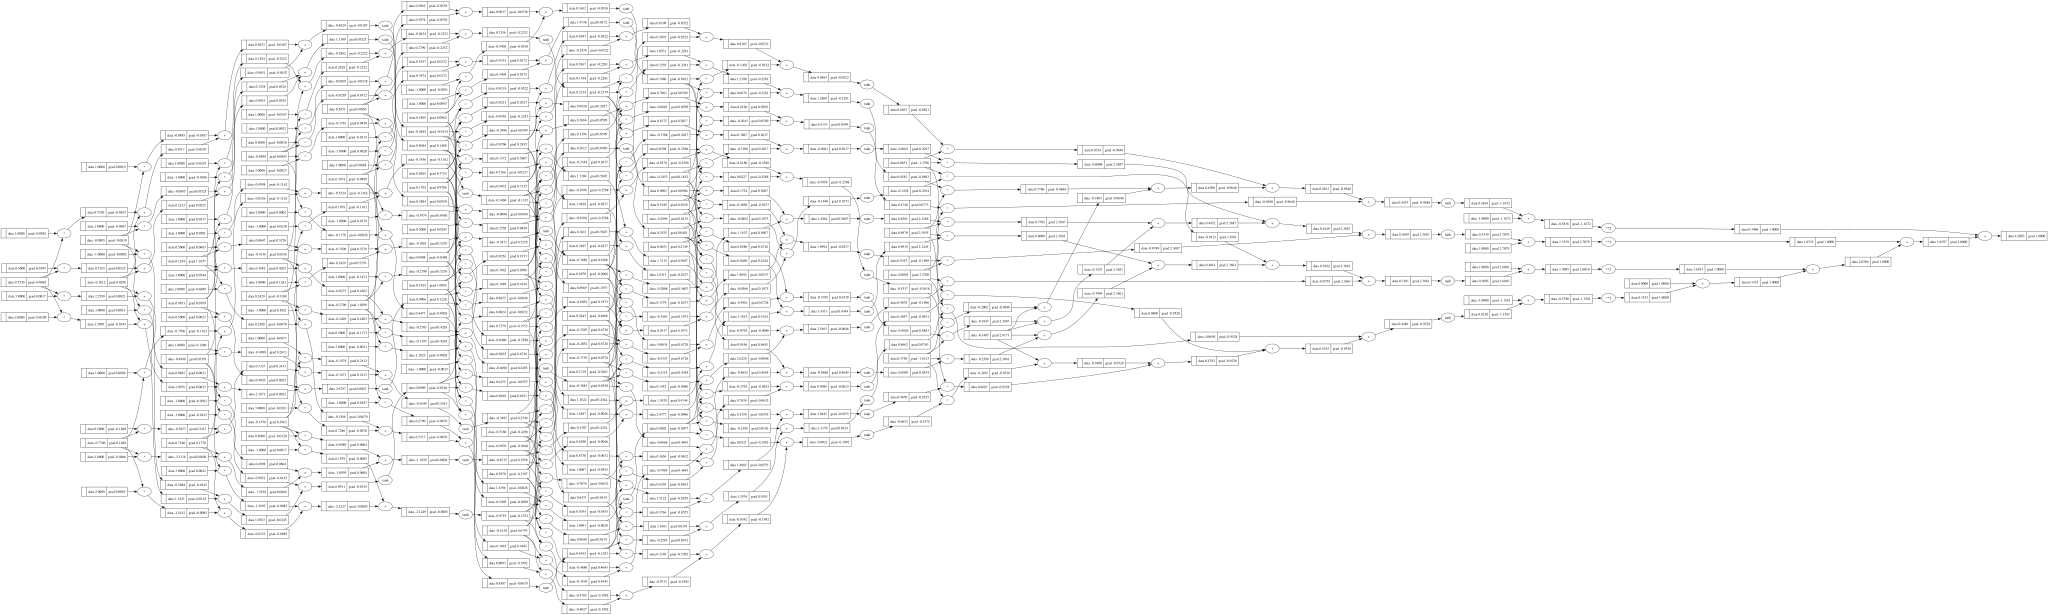

In [31]:
# This will be huge.
draw_dot(loss)

# What does this represent?
# This represents the full computational graph for the entire batch of 4 examples and the resulting total loss (MSE). It contains:
# 4 forward passes through the neural network (one for each input example).
# The loss function calculation combining all 4 predictions into a single scalar value (loss).
# All intermediate computational nodes, operations, weights, biases, and gradients connecting the inputs to the final loss.

# I'm seeing that they all have gradients for all inputs as well. The thing is, these gradients on the input data are not that useful to me. 
# That's because the input data is assumed to be not changeable. 
# It's a given to the problem, and so it's a fixed input.
# We're not going to be changing it or messing with it, even though we do have gradients for it.

# But some of these gradients here in the layers following input layer, will be for the neural network parameters, the w's and the b's, and those, we of course want to change. 
